In [27]:
import cv2
import dlib
import IPython
import numpy as np
from batch_face import RetinaFace

In [7]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [8]:
cap = cv2.VideoCapture('/home/amos/media/tv/Manhunt.2024.S01E03.Let.the.Sheep.Flee.2160p.ATVP.WEB-DL.DDP5.1.HDR.H.265-NTb.mkv')

In [9]:
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
framecount

73523

In [10]:
det = RetinaFace()

In [11]:
for frame_num in range(0, framecount, 1):
    ret, frame = cap.read()
    if frame_num % 24 == 0:
        faces = det(frame)
        if faces:
            break


In [12]:
faces

[(array([1839.2925 ,  671.73413, 1938.6937 ,  799.1672 ], dtype=float32),
  array([[1869.3236 ,  714.5353 ],
         [1914.429  ,  719.97894],
         [1889.477  ,  738.55426],
         [1866.7109 ,  765.2368 ],
         [1900.9104 ,  769.985  ]], dtype=float32),
  0.99954885),
 (array([1623.3848,  578.3663, 1755.6521,  760.1121], dtype=float32),
  array([[1672.8811 ,  642.8403 ],
         [1727.2588 ,  637.28906],
         [1720.2466 ,  660.13135],
         [1694.5516 ,  710.74414],
         [1738.6051 ,  706.1697 ]], dtype=float32),
  0.9991591),
 (array([1252.1528,  508.9488, 1352.4171,  656.1376], dtype=float32),
  array([[1286.6091 ,  553.5008 ],
         [1334.59   ,  558.3744 ],
         [1315.6885 ,  577.17786],
         [1288.6533 ,  611.7267 ],
         [1326.9589 ,  616.30396]], dtype=float32),
  0.99806446),
 (array([2608.9473 ,  593.40594, 2730.3108 ,  779.2536 ], dtype=float32),
  array([[2636.6633 ,  662.6624 ],
         [2656.2183 ,  663.7723 ],
         [2619.2434 , 

In [13]:
cropped = []
for face in faces:
    box, landmarks, confidence = face 
    x1, y1, x2, y2 = [int(x) for x in box]
    img = frame[y1:y2, x1:x2]
    cropped.append(img)

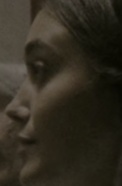

In [14]:
show_image(cropped[3])

In [15]:
resized = [cv2.resize(x, (150, 150)) for x in cropped]

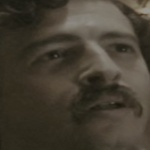

In [16]:
show_image(resized[1])

In [17]:
rec = dlib.face_recognition_model_v1('../data/dlib_face_recognition_resnet_model_v1.dat')

In [29]:
import time
t = time.time()
vectors = rec.compute_face_descriptor(resized)
print(time.time() - t)

0.6706783771514893


In [30]:
t = time.time() 
for i in resized:
    v = rec.compute_face_descriptor(i)
print(time.time() - t)

0.6719491481781006


In [22]:
vector = vectors[0]

In [25]:
len(list(vector))

128

In [28]:
np.array(vector)

array([-0.03665382,  0.06258059,  0.08882789, -0.05056842, -0.12008269,
       -0.00087583, -0.01282646,  0.00668332,  0.09219716, -0.04877163,
        0.16392693, -0.03968348, -0.22234511, -0.07499523, -0.07846223,
        0.12973902, -0.08673206, -0.20291288, -0.13325901, -0.14939742,
        0.06649192,  0.09279519, -0.04838033,  0.05610233, -0.22458918,
       -0.23278141, -0.03897613, -0.1040638 ,  0.00074789, -0.16218567,
       -0.00553162,  0.10875534, -0.20600256, -0.05279621,  0.01238914,
        0.1047236 , -0.05662744, -0.08702595,  0.24996412,  0.07757935,
       -0.16612203,  0.09568428,  0.01992712,  0.32557413,  0.18011969,
       -0.00593785,  0.03467337, -0.00540559,  0.19243278, -0.30692172,
        0.09102911,  0.21564856,  0.1357155 ,  0.15935139,  0.04130649,
       -0.11990584,  0.05034593,  0.1900951 , -0.19686672,  0.13534826,
       -0.02016059, -0.18839855, -0.00232749, -0.06602412,  0.14437278,
        0.05522358, -0.0588364 , -0.13109207,  0.21696088, -0.13